# 01 · Data preprocessing

Builds everything the decoders train on, so no later notebook touches raw JPEGs: the Karpathy split, a word-level vocabulary, and frozen ResNet-50 grid features.

**Outputs** in `data/processed/`: `captions.json`, `vocab.json`, `features_resnet50_7x7_fp16.npy`.

In [1]:
import json
import sys
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import HTML, display
from PIL import Image
from torch.utils.data import DataLoader

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import viz
from src.dataset import CAPTIONS_FILE, FEATURES_FILE, UNK_IDX, VOCAB_FILE, Vocabulary, tokenize
from src.utils import IMAGE_TRANSFORM, RESNET_WEIGHTS, ImagePathDataset, extract_grid_features, load_resnet50, set_seed

viz.setup_style()
RAW = ROOT / "data" / "raw"
IMAGE_DIR = RAW / "Images"
PROCESSED = ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

MIN_WORD_FREQ = 5
set_seed(42)
device = torch.device("cuda")
viz.note(f"PyTorch {torch.__version__} · {torch.cuda.get_device_name(0)}")

## 1. Karpathy split

In [2]:
karpathy = json.loads((RAW / "dataset_flickr30k.json").read_text())["images"]
on_disk = {p.name for p in IMAGE_DIR.glob("*.jpg")}
split_counts = Counter(img["split"] for img in karpathy)

display(viz.table(pd.DataFrame([
    {"item": "train / val / test images", "value": f"{split_counts['train']:,} / {split_counts['val']:,} / {split_counts['test']:,}"},
    {"item": "captions per image", "value": ", ".join(f"{k} (×{v:,})" for k, v in Counter(len(i["sentences"]) for i in karpathy).items())},
    {"item": "split images missing from Images/", "value": f"{sum(img['filename'] not in on_disk for img in karpathy)}"},
    {"item": "images on disk", "value": f"{len(on_disk):,} ({len(on_disk) - len(karpathy)} outside the split, unused)"},
]), caption="Karpathy split"))

item,value
train / val / test images,"29,000 / 1,014 / 1,000"
captions per image,"5 (×31,014)"
split images missing from Images/,0
images on disk,"31,783 (769 outside the split, unused)"


### Cross-check against the Kaggle `captions.txt`
Compared as letters and digits only, because the two files punctuate differently.

In [3]:
kaggle = pd.read_csv(RAW / "captions.txt")


def letters_only(caption):
    return "".join(tokenize(caption))


kaggle_caps = kaggle.dropna().groupby("image").caption.apply(lambda s: sorted(map(letters_only, s))).to_dict()
mismatched = [img["filename"] for img in karpathy
              if kaggle_caps.get(img["filename"]) != sorted(letters_only(s["raw"]) for s in img["sentences"])]
pairs = [(tokenize(s["raw"]), s["tokens"]) for img in karpathy for s in img["sentences"]]
agree = sum(ours == theirs for ours, theirs in pairs)

display(viz.table(pd.DataFrame([
    {"check": "Kaggle rows / empty captions", "result": f"{len(kaggle):,} / {kaggle.caption.isna().sum()} (row {kaggle.index[kaggle.caption.isna()].tolist()})"},
    {"check": "images whose 5 captions differ between the files", "result": f"{len(mismatched)}: {', '.join(mismatched)}"},
    {"check": "our tokenizer == Karpathy's token lists", "result": f"{agree / len(pairs):.2%} of {len(pairs):,} captions"},
]), caption="Caption sources"))
display(viz.table(pd.DataFrame([{"ours": " ".join(o), "Karpathy tokens": " ".join(t)} for o, t in pairs if o != t][:3]),
                  caption="Examples where the tokenizers disagree"))

check,result
Kaggle rows / empty captions,"158,915 / 1 (row [19999])"
images whose 5 captions differ between the files,1: 2199200615.jpg
our tokenizer == Karpathy's token lists,"99.75% of 155,070 captions"


ours,Karpathy tokens
five musicians a man and four women practicing sheet music using flutes in a living room,five musicians a man and four women practicing sheet music (using flutes ) in a living room
a man is cooking a square pancake he lifts it with his fingers and a spatula to check to see if it is done,a man is cooking a square pancake : he lifts it with his fingers and a spatula to check to see if it is done
grocery store employee dressed in a red apron a baseball cap sits on a ledge in front of the store,grocery store employee dressed in a red apron &amp a baseball cap sits on a ledge in front of the store


The one mismatch is an image whose 5th caption is empty in the Kaggle file, so the Karpathy file is the caption source here.

## 2. Caption statistics

train captions,mean words,p50,p90,p95,p99,max,longer than 40 words
"145,000",12.3,11,19,22,30,78,0.13%


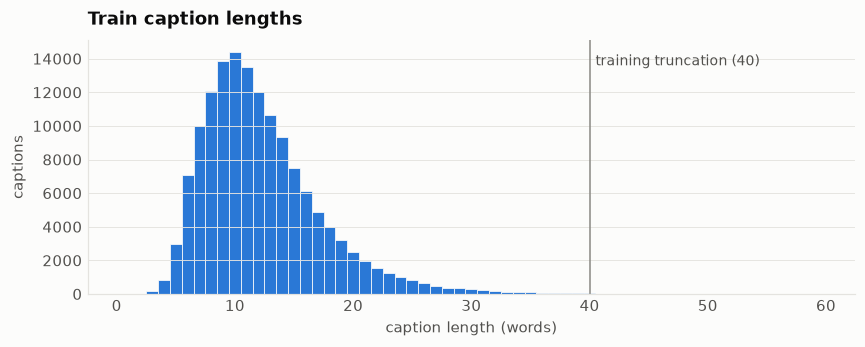

In [4]:
train_imgs = [img for img in karpathy if img["split"] == "train"]
train_tokens = [tokenize(s["raw"]) for img in train_imgs for s in img["sentences"]]
lengths = np.array([len(t) for t in train_tokens])

display(viz.table(pd.DataFrame([{
    "train captions": len(train_tokens), "mean words": lengths.mean(),
    **{f"p{p}": int(np.percentile(lengths, p)) for p in (50, 90, 95, 99)},
    "max": int(lengths.max()), "longer than 40 words": (lengths > 40).mean(),
}]), precision=1, percent=["longer than 40 words"], formats={"longer than 40 words": "{:.2%}"}, caption="Train caption length (words)"))

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(lengths, bins=np.arange(0.5, 60.5, 1), color=viz.SERIES[0], edgecolor=viz.SURFACE, linewidth=0.5)
ax.axvline(40, color=viz.INK_3, lw=1)
ax.text(40.5, ax.get_ylim()[1] * 0.9, "training truncation (40)", color=viz.INK_2, fontsize=9)
ax.set(xlabel="caption length (words)", ylabel="captions", title="Train caption lengths")
ax.grid(axis="x", visible=False)
plt.show()

position_len = np.array([[len(tokenize(s["raw"])) for s in img["sentences"]] for img in karpathy]).mean(axis=0)
viz.note("Mean length by caption position (1st…5th): " + " · ".join(f"{v:.1f}" for v in position_len)
         + ". Flickr30k lists each image's captions roughly longest first, so later notebooks never treat the first reference as a typical human caption.")

## 3. Vocabulary (train split only)

In [5]:
vocab = Vocabulary.build(train_tokens, min_freq=MIN_WORD_FREQ)
vocab.save(PROCESSED / VOCAB_FILE)
counts = Counter(t for tokens in train_tokens for t in tokens)


def unk_stats(token_lists):
    ids = [vocab.encode(t)[1:-1] for t in token_lists]
    n_tokens = sum(len(i) for i in ids)
    return sum(i.count(UNK_IDX) for i in ids) / n_tokens, sum(UNK_IDX in i for i in ids) / len(ids)


rows = []
for split in ("train", "val", "test"):
    toks = [tokenize(s["raw"]) for img in karpathy if img["split"] == split for s in img["sentences"]]
    tok_rate, cap_rate = unk_stats(toks)
    rows.append({"split": split, "tokens that are <unk>": tok_rate, "captions containing <unk>": cap_rate})
display(viz.table(pd.DataFrame(rows), percent=["tokens that are <unk>", "captions containing <unk>"],
                  formats={"tokens that are <unk>": "{:.2%}"},
                  caption=f"Vocabulary: {len(counts):,} distinct train words → {len(vocab):,} tokens with min_freq={MIN_WORD_FREQ} (incl. 4 special)"))
display(viz.table(pd.DataFrame([{"most frequent": ", ".join(vocab.itos[4:24]), "rarest kept": ", ".join(vocab.itos[-10:])}]),
                  caption="Vocabulary extremes"))

split,tokens that are <unk>,captions containing <unk>
train,0.99%,10.6%
val,1.29%,14.0%
test,1.18%,12.4%


most frequent,rarest kept
"a, in, the, on, and, man, is, of, with, woman, two, are, to, people, at, an, wearing, shirt, white, young","whips, wipe, wondering, wonders, woodwork, wrangle, wrench, wristwatch, ymca, zune"


## 4. Caption records
One record per image. `feat_idx` is its row in the feature file.

In [6]:
images = [
    {"filename": img["filename"], "split": img["split"], "feat_idx": i, "captions": [s["raw"] for s in img["sentences"]]}
    for i, img in enumerate(karpathy)
]
(PROCESSED / CAPTIONS_FILE).write_text(json.dumps(images))
viz.note(f"{len(images):,} records written to <code>data/processed/{CAPTIONS_FILE}</code>")
print(json.dumps(images[0], indent=2))

{
  "filename": "1000092795.jpg",
  "split": "train",
  "feat_idx": 0,
  "captions": [
    "Two young guys with shaggy hair look at their hands while hanging out in the yard.",
    "Two young, White males are outside near many bushes.",
    "Two men in green shirts are standing in a yard.",
    "A man in a blue shirt standing in a garden.",
    "Two friends enjoy time spent together."
  ]
}


## 5. ResNet-50 grid features
Frozen `IMAGENET1K_V1` weights, images squash-resized to 224×224 (no crop), `layer4` output = 49 grid vectors per image, stored as float16 (~6.2 GB).

In [7]:
features_path = PROCESSED / FEATURES_FILE
meta_path = PROCESSED / "features_meta.json"

if not features_path.exists():
    resnet = load_resnet50(device)
    loader = DataLoader(ImagePathDataset([IMAGE_DIR / img["filename"] for img in images]),
                        batch_size=128, num_workers=8, pin_memory=True)
    tmp_path = features_path.with_suffix(".partial.npy")
    out = np.lib.format.open_memmap(tmp_path, mode="w+", dtype=np.float16, shape=(len(images), 49, 2048))
    progress = display(HTML("extracting…"), display_id=True)
    start, row = time.time(), 0
    for batch in loader:
        grid = extract_grid_features(resnet, batch.to(device, non_blocking=True))
        out[row : row + len(batch)] = grid.half().cpu().numpy()
        row += len(batch)
        progress.update(HTML(f"{row:,} / {len(images):,} images · {time.time() - start:.0f}s"))
    out.flush()
    del out
    tmp_path.rename(features_path)
    meta_path.write_text(json.dumps({
        "images": len(images), "shape": [len(images), 49, 2048], "dtype": "float16", "weights": "IMAGENET1K_V1",
        "batch_size": 128, "num_workers": 8, "minutes": round((time.time() - start) / 60, 2),
        "gpu": torch.cuda.get_device_name(0), "size_gb": round(features_path.stat().st_size / 1e9, 2),
    }, indent=2))

meta = json.loads(meta_path.read_text())
display(viz.table(pd.DataFrame([{"item": k, "value": str(v)} for k, v in meta.items()]), caption="Feature extraction"))

item,value
images,31014
shape,"[31014, 49, 2048]"
dtype,float16
weights,IMAGENET1K_V1
batch_size,128
num_workers,8
minutes,1.4
gpu,NVIDIA GeForce RTX 5050 Laptop GPU
size_gb,6.22


## 6. Sanity checks
Values finite and inside float16 range, stored features match a fresh extraction, and ResNet's own classifier still labels them sensibly.

check,result
array shape / dtype,"(31014, 49, 2048) / float16"
"max activation (float16 max is 65,504)",41.2
non-finite values,0
zeros (ReLU sparsity),44.6%
float16 rounding alone (mean relative error),1.76e-04
stored vs fresh float32 extraction (mean relative error),2.06e-03


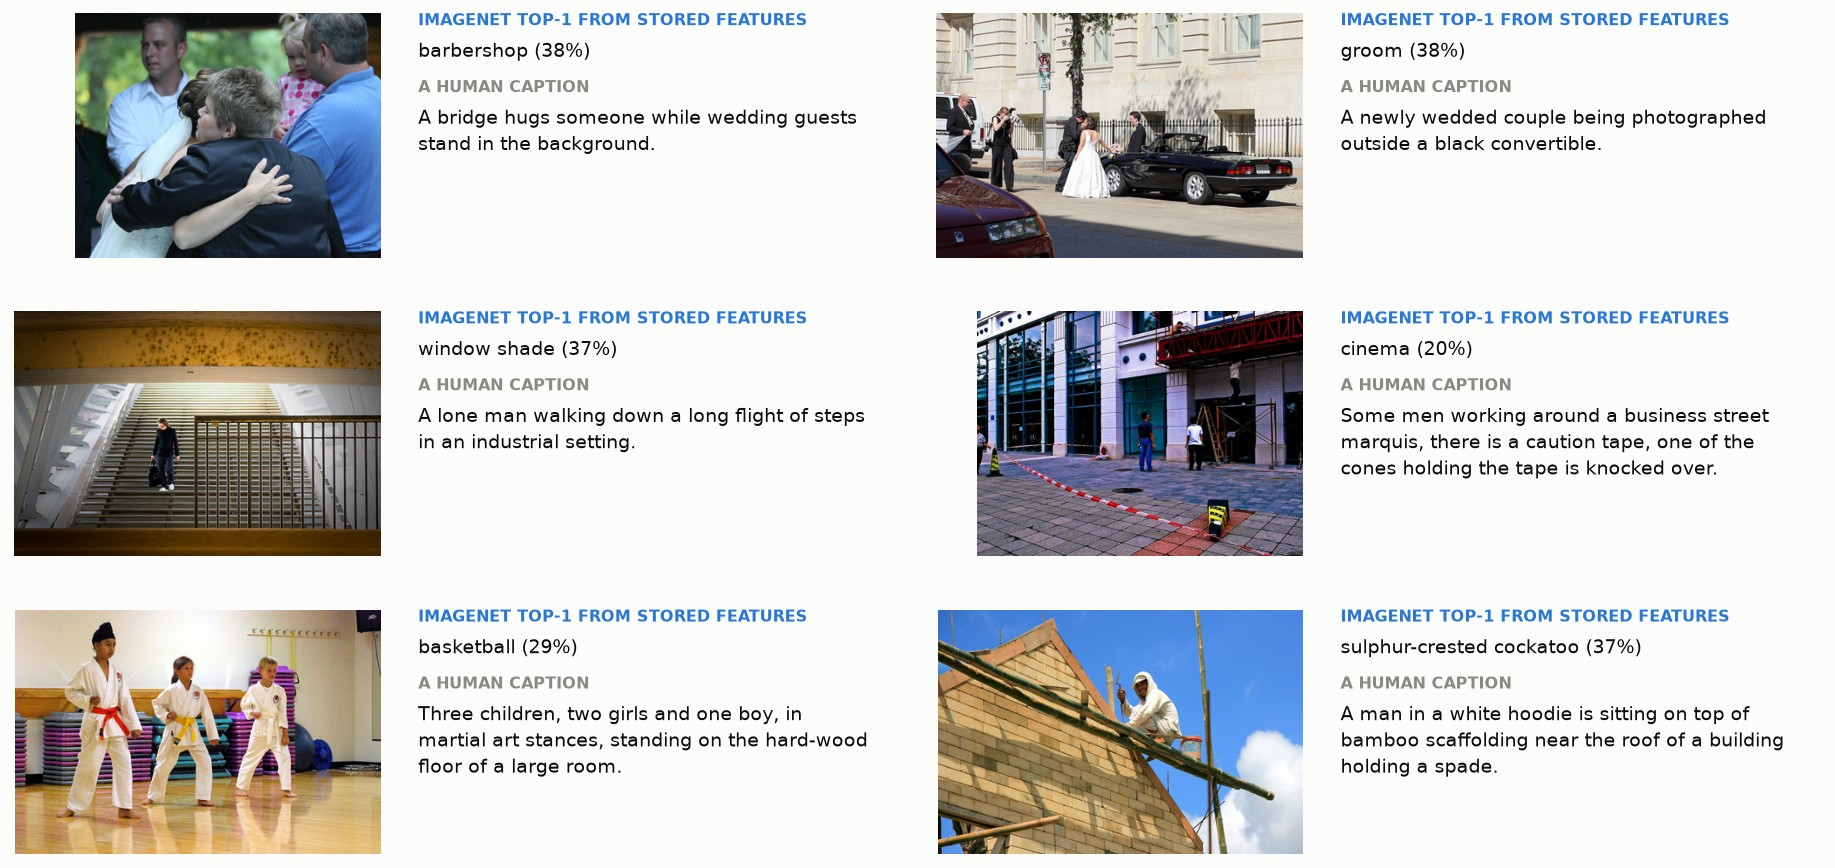

In [8]:
features = np.load(features_path, mmap_mode="r")
max_val, n_nonfinite, n_zero = 0.0, 0, 0
for s in range(0, len(features), 512):
    chunk = np.asarray(features[s : s + 512], dtype=np.float32)
    max_val = max(max_val, float(chunk.max()))
    n_nonfinite += int((~np.isfinite(chunk)).sum())
    n_zero += int((chunk == 0).sum())

resnet = load_resnet50(device)
sample = np.random.default_rng(0).choice(len(images), 6, replace=False)
batch = torch.stack([IMAGE_TRANSFORM(Image.open(IMAGE_DIR / images[i]["filename"]).convert("RGB")) for i in sample])
fresh = extract_grid_features(resnet, batch.to(device)).cpu().numpy()
stored = np.asarray(features[sample], dtype=np.float32)


def rel_err(a, b):
    return np.abs(a - b).sum() / np.abs(a).sum()


display(viz.table(pd.DataFrame([
    {"check": "array shape / dtype", "result": f"{features.shape} / {features.dtype}"},
    {"check": "max activation (float16 max is 65,504)", "result": f"{max_val:.1f}"},
    {"check": "non-finite values", "result": f"{n_nonfinite}"},
    {"check": "zeros (ReLU sparsity)", "result": f"{n_zero / features.size:.1%}"},
    {"check": "float16 rounding alone (mean relative error)", "result": f"{rel_err(fresh, fresh.astype(np.float16).astype(np.float32)):.2e}"},
    # Also includes cuDNN picking different (TF32) conv kernels for a batch of 6 vs a batch of 128.
    {"check": "stored vs fresh float32 extraction (mean relative error)", "result": f"{rel_err(fresh, stored):.2e}"},
]), caption="Stored features"))

with torch.no_grad():
    probs = resnet.fc(torch.from_numpy(stored).to(device).mean(dim=1)).softmax(-1)
top_p, top_c = probs.max(-1)
labels = RESNET_WEIGHTS.meta["categories"]
viz.show_captions([
    {"filename": images[i]["filename"], "captions": [("ImageNet top-1 from stored features", f"{labels[c]} ({p:.0%})"),
                                                     ("a human caption", images[i]["captions"][0])]}
    for i, p, c in zip(sample, top_p.tolist(), top_c.tolist())
], IMAGE_DIR, colors={"ImageNet top-1 from stored features": viz.SERIES[0], "a human caption": viz.INK_3})

## Summary

- Karpathy split: 29,000 / 1,014 / 1,000 images, 5 captions each, all present on disk.
- Vocabulary: 7,414 tokens (min frequency 5); about 1% of tokens become `<unk>`.
- Features: 31,014 × 49 × 2048 float16, extracted in ~1.4 min, 0.02% rounding error.